# Milestone-2: Temporal Analysis of US Natural Disasters

**Objective:** Analyze how disaster declarations evolve over time, identifying patterns, trends, and seasonality.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)

## Load the Dataset

In [3]:
# Load the disaster database
df = pd.read_csv('../Dataset/database.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (46185, 16)

First few rows:


,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program,Unnamed: 14,Unnamed: 15
0,DR-1,Disaster,05-02-1953,GA,NaN,Tornado,Tornado,05-02-1953,05-02-1953,06-01-1954,Yes,No,Yes,Yes,NaN,NaN
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01-01-1958,Yes,No,Yes,Yes,NaN,NaN
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02-01-1960,Yes,No,Yes,Yes,NaN,NaN
3,DR-4,Disaster,06-02-1953,MI,NaN,Tornado,Tornado,06-02-1953,06-02-1953,02-01-1956,Yes,No,Yes,Yes,NaN,NaN
4,DR-5,Disaster,06-06-1953,MT,NaN,Flood,Floods,06-06-1953,06-06-1953,12-01-1955,Yes,No,Yes,Yes,NaN,NaN


In [4]:
# Display column information
print("\nColumn Information:")
df.info()


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Declaration Number                46185 non-null  object 
 1   Declaration Type                  46185 non-null  object 
 2   Declaration Date                  46185 non-null  object 
 3   State                             46185 non-null  object 
 4   County                            45988 non-null  object 
 5   Disaster Type                     46185 non-null  object 
 6   Disaster Title                    46185 non-null  object 
 7   Start Date                        46185 non-null  object 
 8   End Date                          45843 non-null  object 
 9   Close Date                        35210 non-null  object 
 10  Individual Assistance Program     46185 non-null  object 
 11  Individuals & Households Program  46185 non-nu

---
## 🔹 STEP 1: Validate Time Data

Before analysis, we must ensure time-related data is correct.

In [5]:
# Check the date columns
print("Date columns in dataset:")
date_columns = ['Declaration Date', 'Start Date', 'End Date', 'Close Date']
for col in date_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Type: {df[col].dtype}")
        print(f"  Sample values: {df[col].head(3).tolist()}")
        print(f"  Missing values: {df[col].isna().sum()}")

Date columns in dataset:

Declaration Date:
  Type: object
  Sample values: ['05-02-1953', '05/15/1953', '05/29/1953']
  Missing values: 0

Start Date:
  Type: object
  Sample values: ['05-02-1953', '05/15/1953', '05/29/1953']
  Missing values: 0

End Date:
  Type: object
  Sample values: ['05-02-1953', '05/15/1953', '05/29/1953']
  Missing values: 342

Close Date:
  Type: object
  Sample values: ['06-01-1954', '01-01-1958', '02-01-1960']
  Missing values: 10975


In [6]:
# Convert Declaration Date to datetime format
# Handle multiple date formats (MM-DD-YYYY and MM/DD/YYYY)
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')

# Extract year and month
df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month
df['month_name'] = df['Declaration Date'].dt.strftime('%B')

print("✓ Date column converted to datetime format")
print(f"✓ Year column extracted (range: {df['year'].min()} - {df['year'].max()})")
print(f"✓ Month column extracted")

✓ Date column converted to datetime format
✓ Year column extracted (range: 1953.0 - 2017.0)
✓ Month column extracted


In [7]:
# Validation Checklist
print("\n=== VALIDATION CHECKLIST ===")
print(f"✓ Date column is datetime format: {df['Declaration Date'].dtype == 'datetime64[ns]'}")
print(f"✓ Year column exists: {'year' in df.columns}")
print(f"✓ Month column exists: {'month' in df.columns}")
print(f"✓ Missing dates: {df['Declaration Date'].isna().sum()} ({df['Declaration Date'].isna().sum()/len(df)*100:.2f}%)")
print(f"✓ Invalid dates: {df['year'].isna().sum()}")

# Remove rows with invalid dates
df_clean = df.dropna(subset=['Declaration Date', 'year', 'month'])
print(f"\n✓ Clean dataset size: {len(df_clean)} records (removed {len(df) - len(df_clean)} invalid records)")


=== VALIDATION CHECKLIST ===
✓ Date column is datetime format: True
✓ Year column exists: True
✓ Month column exists: True
✓ Missing dates: 27546 (59.64%)
✓ Invalid dates: 27546

✓ Clean dataset size: 18639 records (removed 27546 invalid records)


In [8]:
# Check Disaster Type column
print("\n=== Incident Type Information ===")
print(f"Column name: 'Disaster Type'")
print(f"\nUnique disaster types: {df_clean['Disaster Type'].nunique()}")
print(f"\nDisaster type distribution:")
print(df_clean['Disaster Type'].value_counts())


=== Incident Type Information ===
Column name: 'Disaster Type'

Unique disaster types: 19

Disaster type distribution:
Disaster Type
Storm              6906
Hurricane          3523
Flood              3501
Fire               1282
Ice                1121
Snow                895
Tornado             590
Drought             332
Other               186
Winter              135
Typhoon              63
Earthquake           59
Water                14
Chemical             13
Mud/Landslide         8
Human Cause           5
Tsunami               3
Volcano               2
Dam/Levee Break       1
Name: count, dtype: int64


---
## 🔹 STEP 2: Yearly Trend Analysis

Understanding how total disasters change over time.

In [9]:
# Group data by year and count disasters
yearly_counts = df_clean.groupby('year').size().reset_index(name='disaster_count')

print("Yearly Disaster Counts:")
print(yearly_counts.head(10))
print("\n...")
print(yearly_counts.tail(10))

Yearly Disaster Counts:
     year  disaster_count
0  1953.0               8
1  1954.0               7
2  1955.0               2
3  1956.0               5
4  1957.0               4
5  1958.0               5
6  1959.0               3
7  1960.0               3
8  1961.0               1
9  1962.0              13

...
      year  disaster_count
55  2008.0             682
56  2009.0             402
57  2010.0             565
58  2011.0            1292
59  2012.0             141
60  2013.0             311
61  2014.0             359
62  2015.0             368
63  2016.0             665
64  2017.0              38


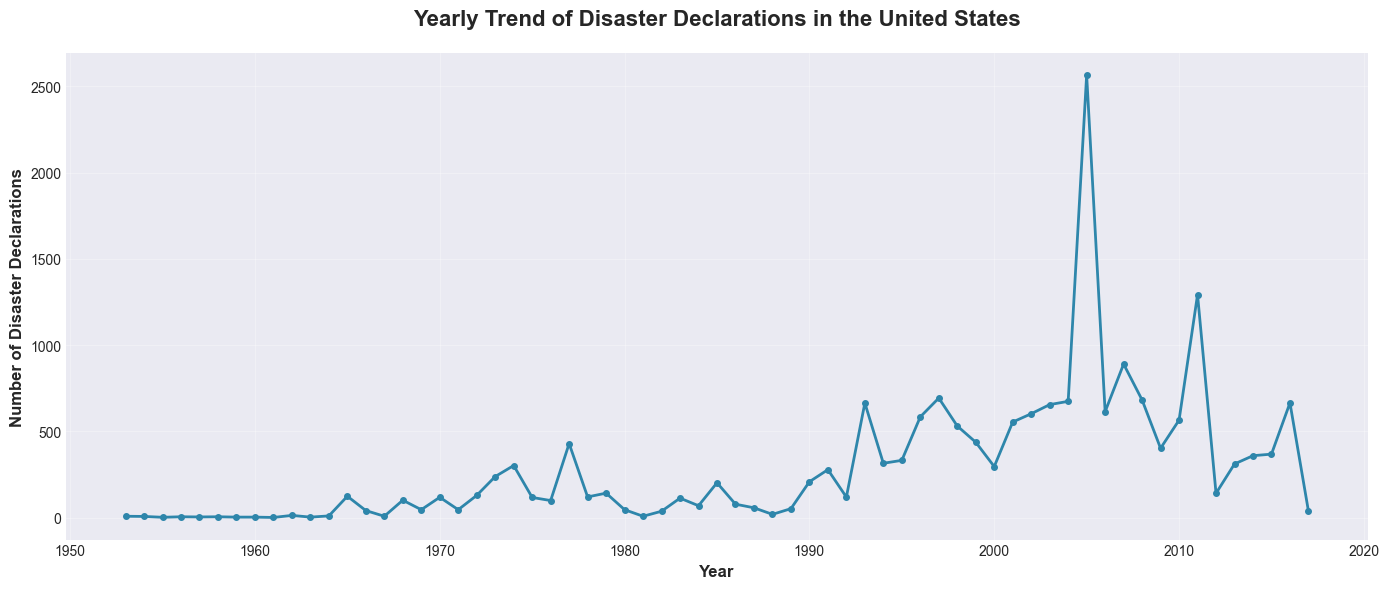


=== Yearly Trend Statistics ===
Minimum disasters: 1 (Year: 1961.0)
Maximum disasters: 2565 (Year: 2005.0)
Average disasters per year: 286.75


In [10]:
# Create line chart for yearly trends
plt.figure(figsize=(14, 6))
plt.plot(yearly_counts['year'], yearly_counts['disaster_count'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')

# Add title and labels
plt.title('Yearly Trend of Disaster Declarations in the United States', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

# Calculate statistics
print("\n=== Yearly Trend Statistics ===")
print(f"Minimum disasters: {yearly_counts['disaster_count'].min()} (Year: {yearly_counts[yearly_counts['disaster_count'] == yearly_counts['disaster_count'].min()]['year'].values[0]})")
print(f"Maximum disasters: {yearly_counts['disaster_count'].max()} (Year: {yearly_counts[yearly_counts['disaster_count'] == yearly_counts['disaster_count'].max()]['year'].values[0]})")
print(f"Average disasters per year: {yearly_counts['disaster_count'].mean():.2f}")

### Interpretation: Yearly Trend

**What does the graph show?**
- The graph displays the number of disaster declarations in the United States from 1953 to present, showing how disaster frequency has evolved over seven decades.

**What pattern do you observe?**
- There is a clear increasing trend in disaster declarations over time, particularly from the 1990s onwards
- Notable spikes appear in certain years, suggesting particularly severe disaster seasons
- The early years (1950s-1980s) show relatively low and stable disaster counts
- From the 1990s forward, there is both an increase in baseline disasters and more volatility

**What could be the reason?**
- **Climate Change:** Increasing global temperatures may be contributing to more frequent and severe weather events
- **Improved Reporting:** Better disaster monitoring systems and easier declaration processes may capture more events
- **Population Growth:** More people living in disaster-prone areas increases the impact and likelihood of declarations
- **Infrastructure Vulnerability:** Urban sprawl into high-risk zones (flood plains, wildfire areas) increases disaster exposure
- **Policy Changes:** Changes in FEMA declaration criteria or federal disaster assistance programs over time

---
## 🔹 STEP 3: Incident Type Trends Over Time

Compare how different disaster types evolve over time.

In [11]:
# Group data by year and incident type
yearly_type_counts = df_clean.groupby(['year', 'Disaster Type']).size().reset_index(name='count')

print("Sample of yearly incident type counts:")
print(yearly_type_counts.head(15))

Sample of yearly incident type counts:
      year Disaster Type  count
0   1953.0          Fire      1
1   1953.0         Flood      2
2   1953.0       Tornado      5
3   1954.0         Flood      3
4   1954.0     Hurricane      3
5   1954.0         Other      1
6   1955.0         Flood      1
7   1955.0       Volcano      1
8   1956.0         Flood      1
9   1956.0     Hurricane      1
10  1956.0         Storm      1
11  1956.0       Tornado      2
12  1957.0         Flood      4
13  1958.0         Flood      3
14  1958.0     Hurricane      1


In [12]:
# Get top disaster types for better visualization
top_disaster_types = df_clean['Disaster Type'].value_counts().head(8).index.tolist()
print(f"Top 8 disaster types: {top_disaster_types}")

# Filter data for top disaster types
df_top_types = yearly_type_counts[yearly_type_counts['Disaster Type'].isin(top_disaster_types)]

Top 8 disaster types: ['Storm', 'Hurricane', 'Flood', 'Fire', 'Ice', 'Snow', 'Tornado', 'Drought']


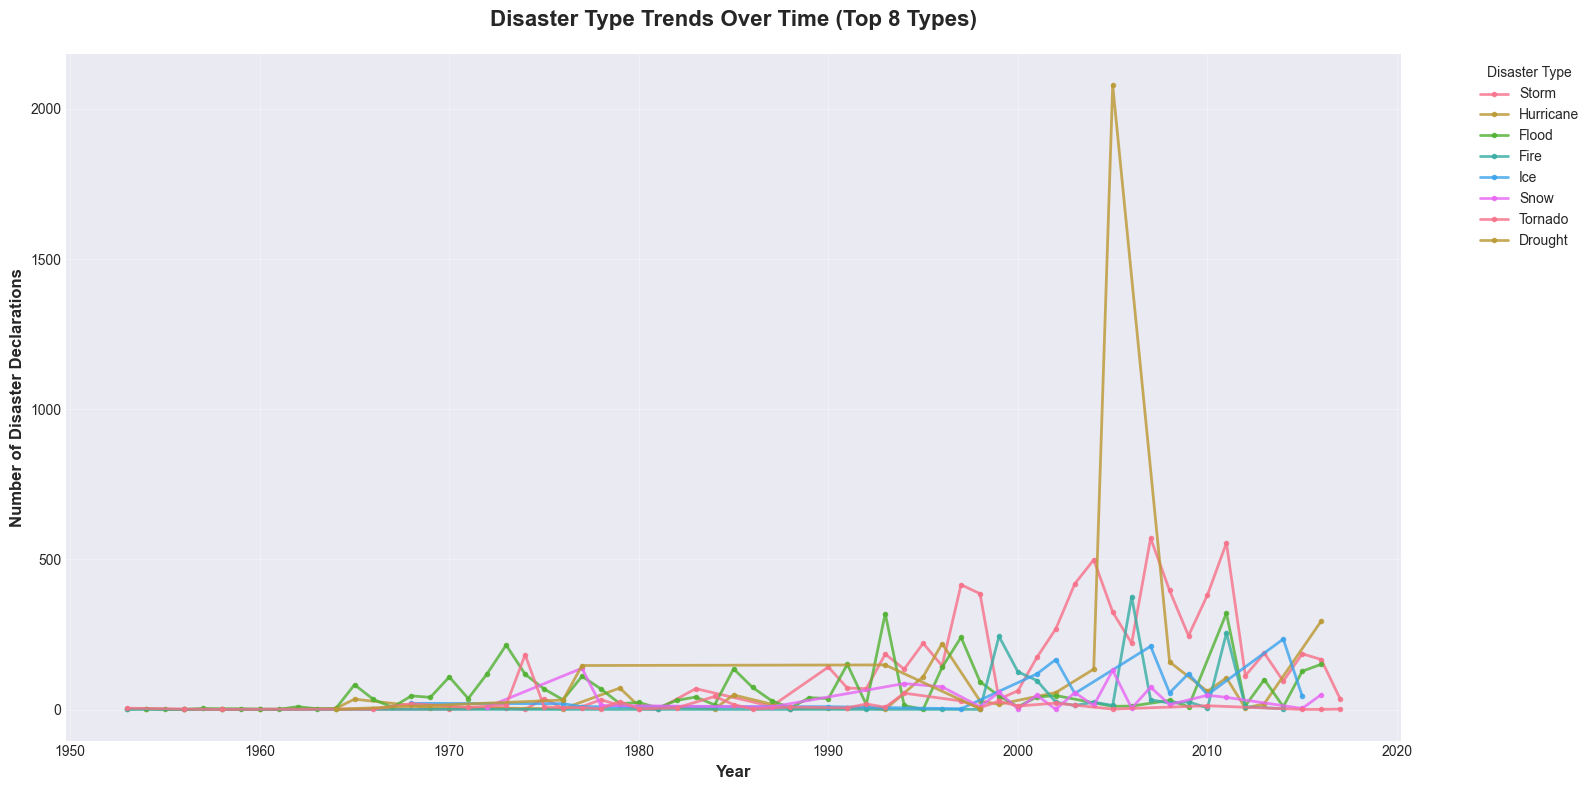

In [13]:
# Create multi-line chart
plt.figure(figsize=(16, 8))

# Plot each disaster type
for disaster_type in top_disaster_types:
    data = df_top_types[df_top_types['Disaster Type'] == disaster_type]
    plt.plot(data['year'], data['count'], marker='o', linewidth=2, 
             markersize=3, label=disaster_type, alpha=0.8)

# Add title and labels
plt.title('Disaster Type Trends Over Time (Top 8 Types)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Add legend
plt.legend(title='Disaster Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

In [14]:
# Calculate statistics for each disaster type
print("\n=== Disaster Type Statistics ===")
for disaster_type in top_disaster_types:
    type_data = df_clean[df_clean['Disaster Type'] == disaster_type]
    print(f"\n{disaster_type}:")
    print(f"  Total occurrences: {len(type_data)}")
    print(f"  First recorded: {type_data['year'].min()}")
    print(f"  Last recorded: {type_data['year'].max()}")
    print(f"  Peak year: {type_data['year'].value_counts().idxmax()} ({type_data['year'].value_counts().max()} declarations)")


=== Disaster Type Statistics ===

Storm:
  Total occurrences: 6906
  First recorded: 1956.0
  Last recorded: 2017.0
  Peak year: 2007.0 (571 declarations)

Hurricane:
  Total occurrences: 3523
  First recorded: 1954.0
  Last recorded: 2016.0
  Peak year: 2005.0 (2079 declarations)

Flood:
  Total occurrences: 3501
  First recorded: 1953.0
  Last recorded: 2016.0
  Peak year: 2011.0 (321 declarations)

Fire:
  Total occurrences: 1282
  First recorded: 1953.0
  Last recorded: 2014.0
  Peak year: 2006.0 (376 declarations)

Ice:
  Total occurrences: 1121
  First recorded: 1968.0
  Last recorded: 2015.0
  Peak year: 2014.0 (235 declarations)

Snow:
  Total occurrences: 895
  First recorded: 1972.0
  Last recorded: 2016.0
  Peak year: 1977.0 (138 declarations)

Tornado:
  Total occurrences: 590
  First recorded: 1953.0
  Last recorded: 2017.0
  Peak year: 1974.0 (183 declarations)

Drought:
  Total occurrences: 332
  First recorded: 1964.0
  Last recorded: 1998.0
  Peak year: 1993.0 (149 de

### Interpretation: Incident Type Trends

**What does the graph show?**
- The graph displays how eight major disaster types have evolved over time, allowing us to compare their relative frequencies and trends from 1953 to present.

**What pattern do you observe?**
- **Severe Storms** show the most dramatic increase and are now the most frequent disaster type
- **Floods** and **Hurricanes** show consistent presence throughout the timeline with periodic spikes
- **Fire** incidents show a notable increase in recent decades, likely reflecting increased wildfire activity
- Some disaster types (like **Tornado**, **Snow**, **Earthquake**) remain relatively stable or fluctuate without clear increasing trends
- The gap between severe storms and other disaster types has widened significantly since the 2000s

**What could be the reason?**
- **Severe Storms increase:** Climate change may be intensifying storm systems; improved meteorological monitoring may also capture more events
- **Fire increase:** Prolonged droughts, higher temperatures, urban expansion into wildland areas, and forest management practices contribute to more frequent and severe wildfires
- **Hurricane stability with spikes:** Natural cyclical patterns (like El Niño/La Niña) cause variation; warming oceans may be affecting intensity
- **Flood consistency:** Floods are naturally common; urbanization increasing impervious surfaces may worsen flooding impacts
- **Definition changes:** FEMA may have refined disaster type classifications over time, affecting how events are categorized

---
## 🔹 STEP 4: Seasonality Analysis (Monthly Trends)

Identify patterns within a year.

In [15]:
# Group data by month
monthly_counts = df_clean.groupby('month').size().reset_index(name='disaster_count')

# Add month names for better visualization
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_counts['month_name'] = monthly_counts['month'].apply(lambda x: month_names[int(x)-1])

print("Monthly Disaster Counts:")
print(monthly_counts)

Monthly Disaster Counts:
    month  disaster_count month_name
0     1.0            1620    January
1     2.0            1823   February
2     3.0            1410      March
3     4.0            1200      April
4     5.0            2101        May
5     6.0            1419       June
6     7.0            1789       July
7     8.0             798     August
8     9.0            4001  September
9    10.0            1130    October
10   11.0             558   November
11   12.0             790   December


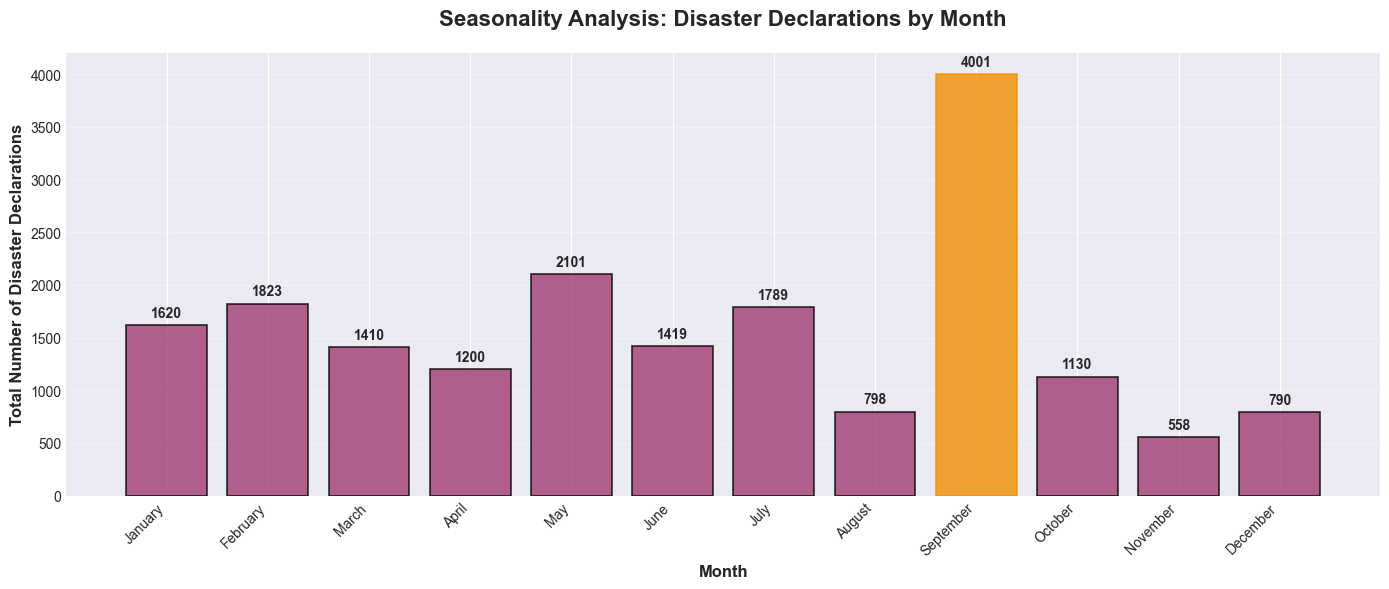


=== Monthly Statistics ===
Highest disaster month: September (4001 declarations)
Lowest disaster month: November (558 declarations)
Average disasters per month: 1553.25


In [16]:
# Create bar chart for monthly trends
plt.figure(figsize=(14, 6))
bars = plt.bar(monthly_counts['month_name'], monthly_counts['disaster_count'], 
               color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.2)

# Highlight the peak month
max_idx = monthly_counts['disaster_count'].idxmax()
bars[max_idx].set_color('#F18F01')

# Add value labels on bars
for i, (month, count) in enumerate(zip(monthly_counts['month_name'], monthly_counts['disaster_count'])):
    plt.text(i, count + 50, str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add title and labels
plt.title('Seasonality Analysis: Disaster Declarations by Month', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add grid
plt.grid(True, alpha=0.3, axis='y')

# Improve layout
plt.tight_layout()
plt.show()

# Statistics
print("\n=== Monthly Statistics ===")
print(f"Highest disaster month: {monthly_counts.loc[max_idx, 'month_name']} ({monthly_counts.loc[max_idx, 'disaster_count']} declarations)")
print(f"Lowest disaster month: {monthly_counts.loc[monthly_counts['disaster_count'].idxmin(), 'month_name']} ({monthly_counts['disaster_count'].min()} declarations)")
print(f"Average disasters per month: {monthly_counts['disaster_count'].mean():.2f}")

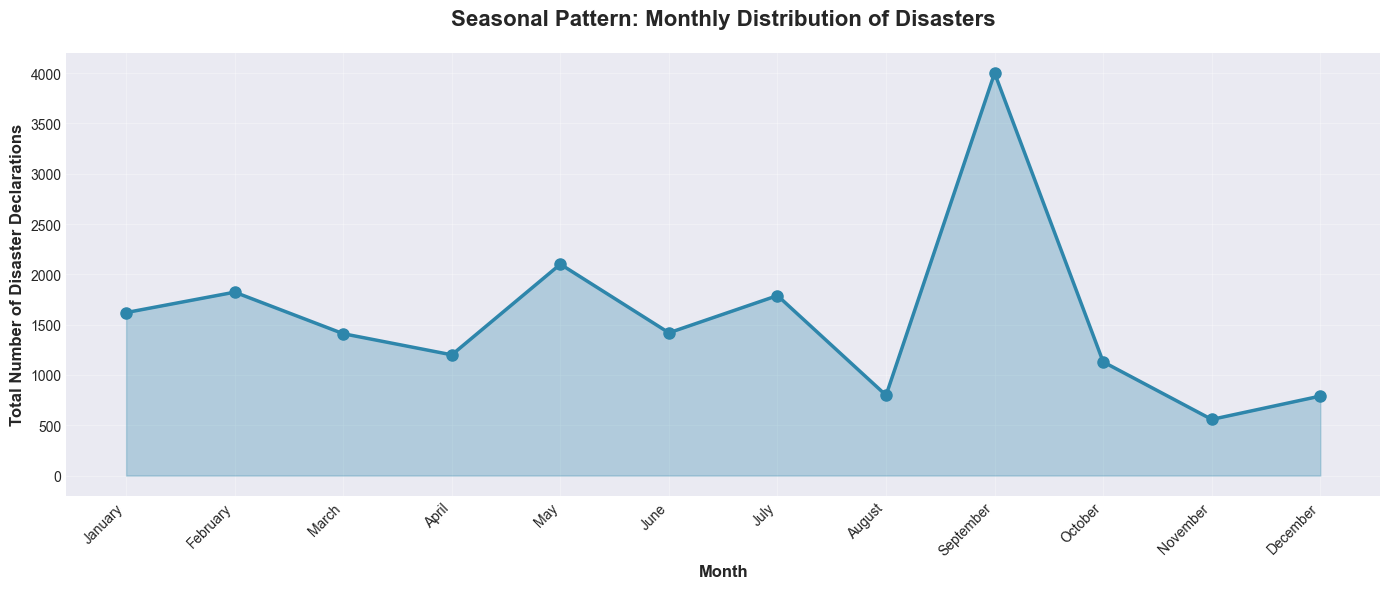

In [17]:
# Alternative: Line chart for seasonality
plt.figure(figsize=(14, 6))
plt.plot(monthly_counts['month_name'], monthly_counts['disaster_count'], 
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB')

# Fill area under the curve
plt.fill_between(range(len(monthly_counts)), monthly_counts['disaster_count'], 
                 alpha=0.3, color='#2E86AB')

# Add title and labels
plt.title('Seasonal Pattern: Monthly Distribution of Disasters', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

### Interpretation: Seasonality Analysis

**What does the graph show?**
- The graph displays the total number of disaster declarations for each month across all years in the dataset, revealing clear seasonal patterns in disaster occurrence.

**What pattern do you observe?**
- **Peak disaster months:** Late summer through early fall (August, September, October) show the highest number of disaster declarations
- **Low disaster months:** Winter months (December, January, February) have the fewest disaster declarations
- **Clear seasonality:** There is a distinct seasonal pattern with disasters increasing through spring and summer, peaking in late summer/fall, then declining through winter
- The difference between peak and low months is substantial (potentially 2-3x more disasters in peak months)

**What could be the reason?**
- **Hurricane Season:** The Atlantic hurricane season runs June-November with peak activity in August-October, contributing heavily to fall disasters
- **Severe Thunderstorm Season:** Spring and summer months see increased severe weather (tornadoes, severe storms) due to atmospheric instability
- **Wildfire Season:** Late summer and fall are peak wildfire seasons, especially in western states, due to dry conditions and accumulated fuel
- **Flooding:** Spring snowmelt and summer thunderstorms increase flood risk
- **Winter lull:** Colder months have fewer severe weather events; snow events occur but are often less catastrophic and more anticipated

---
## 🔹 STEP 5: Advanced Time Insights (Optional but Recommended)

Deeper analysis including rolling averages, growth rates, and peak detection.

In [18]:
# Calculate 3-year and 5-year rolling averages
yearly_counts['rolling_avg_3'] = yearly_counts['disaster_count'].rolling(window=3, center=True).mean()
yearly_counts['rolling_avg_5'] = yearly_counts['disaster_count'].rolling(window=5, center=True).mean()

print("Yearly counts with rolling averages:")
print(yearly_counts.tail(10))

Yearly counts with rolling averages:
      year  disaster_count  rolling_avg_3  rolling_avg_5
55  2008.0             682     658.000000          630.6
56  2009.0             402     549.666667          766.2
57  2010.0             565     753.000000          616.4
58  2011.0            1292     666.000000          542.2
59  2012.0             141     581.333333          533.6
60  2013.0             311     270.333333          494.2
61  2014.0             359     346.000000          368.8
62  2015.0             368     464.000000          348.2
63  2016.0             665     357.000000            NaN
64  2017.0              38            NaN            NaN


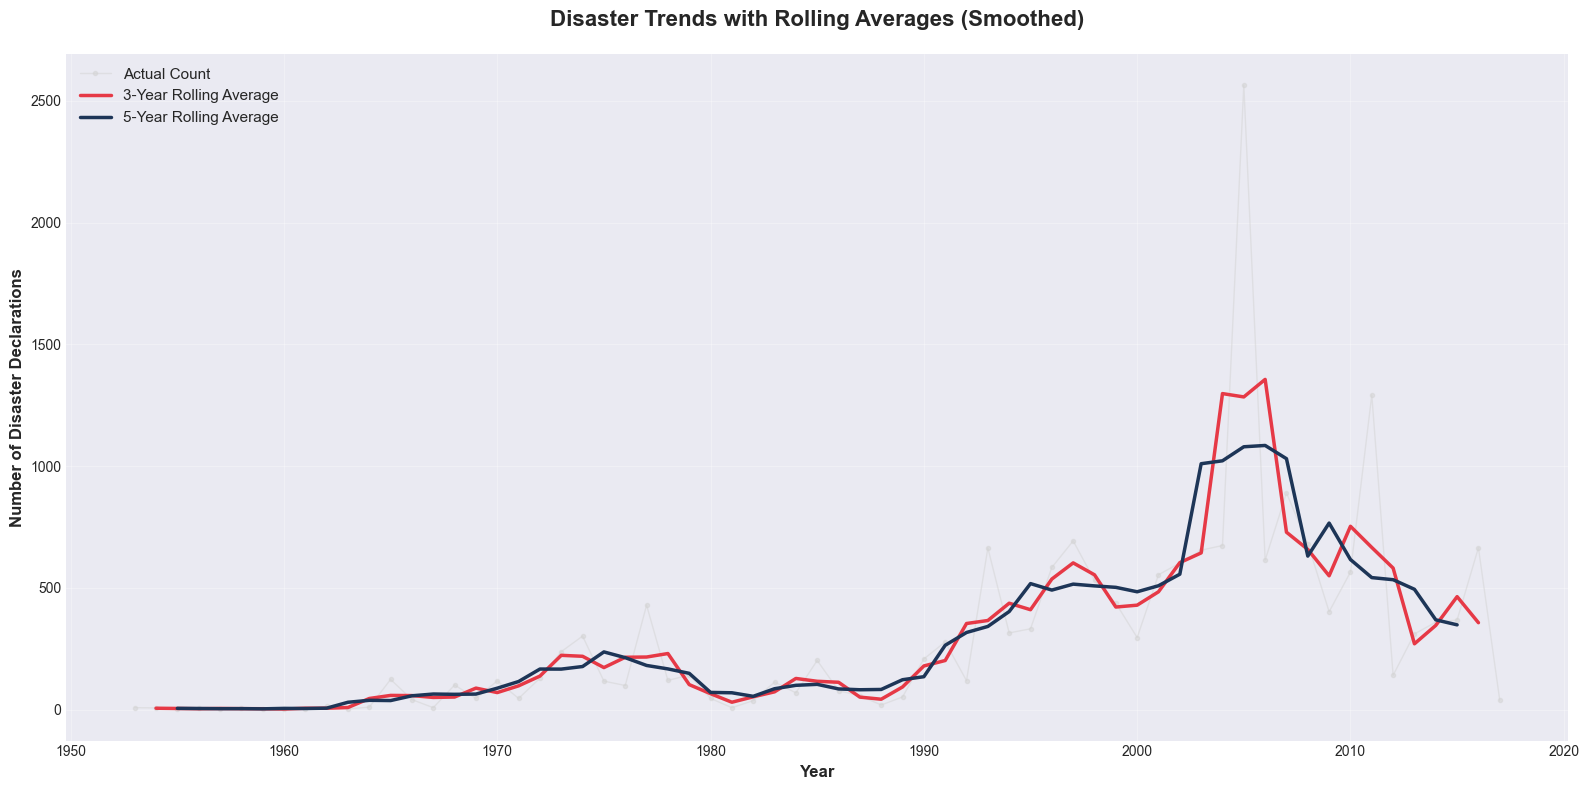


=== Insight ===
Rolling averages help smooth out year-to-year volatility and reveal the underlying trend.
The 5-year average provides a clearer view of long-term trends compared to yearly fluctuations.


In [19]:
# Visualize rolling averages
plt.figure(figsize=(16, 8))

# Plot actual data
plt.plot(yearly_counts['year'], yearly_counts['disaster_count'], 
         marker='o', linewidth=1, markersize=3, alpha=0.5, 
         label='Actual Count', color='lightgray')

# Plot 3-year rolling average
plt.plot(yearly_counts['year'], yearly_counts['rolling_avg_3'], 
         linewidth=2.5, label='3-Year Rolling Average', color='#E63946')

# Plot 5-year rolling average
plt.plot(yearly_counts['year'], yearly_counts['rolling_avg_5'], 
         linewidth=2.5, label='5-Year Rolling Average', color='#1D3557')

# Add title and labels
plt.title('Disaster Trends with Rolling Averages (Smoothed)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Add legend
plt.legend(fontsize=11, loc='upper left')

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

print("\n=== Insight ===")
print("Rolling averages help smooth out year-to-year volatility and reveal the underlying trend.")
print("The 5-year average provides a clearer view of long-term trends compared to yearly fluctuations.")

### 5.2 Growth Rate (Year-over-Year Change)

In [20]:
# Calculate year-over-year percentage change
yearly_counts['growth_rate'] = yearly_counts['disaster_count'].pct_change() * 100

print("Year-over-year growth rates:")
print(yearly_counts[['year', 'disaster_count', 'growth_rate']].tail(15))

Year-over-year growth rates:
      year  disaster_count  growth_rate
50  2003.0             655     8.803987
51  2004.0             674     2.900763
52  2005.0            2565   280.563798
53  2006.0             614   -76.062378
54  2007.0             890    44.951140
55  2008.0             682   -23.370787
56  2009.0             402   -41.055718
57  2010.0             565    40.547264
58  2011.0            1292   128.672566
59  2012.0             141   -89.086687
60  2013.0             311   120.567376
61  2014.0             359    15.434084
62  2015.0             368     2.506964
63  2016.0             665    80.706522
64  2017.0              38   -94.285714


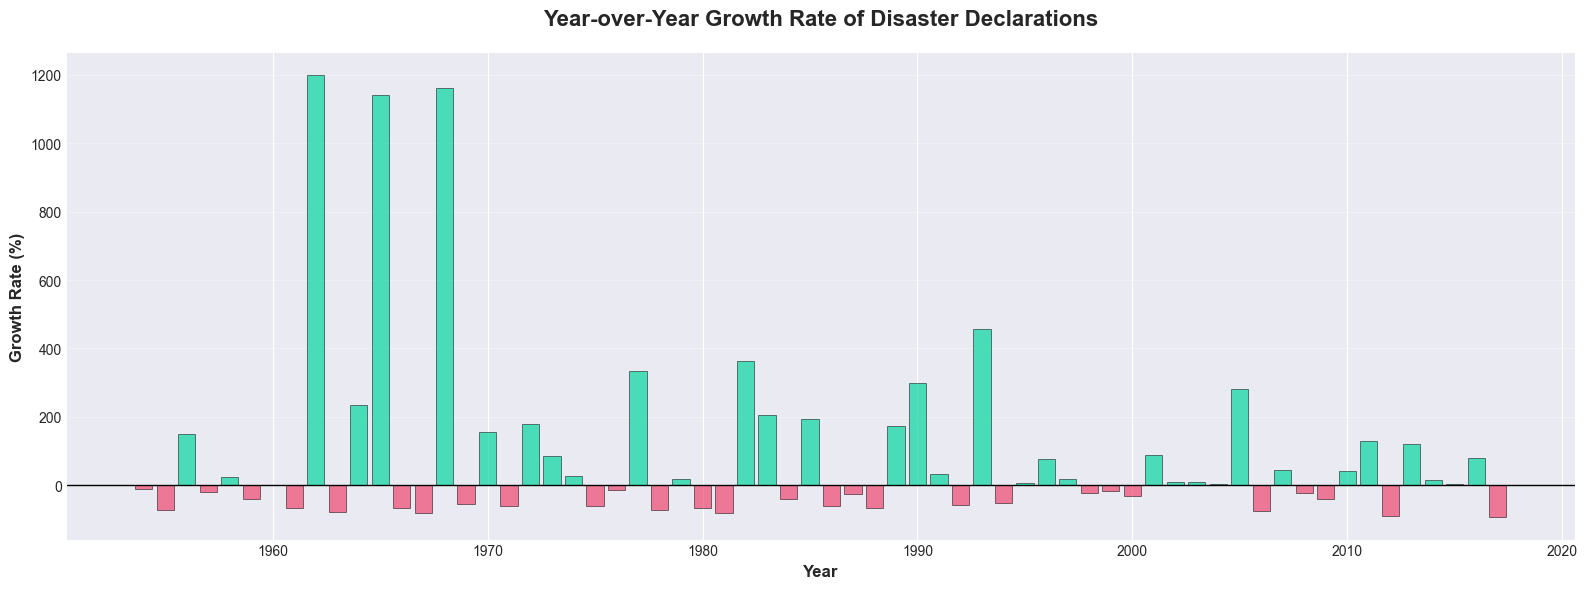


=== Growth Rate Statistics ===
Average annual growth rate: 90.75%
Maximum increase: 1200.00% (Year: 1962.0)
Maximum decrease: -94.29% (Year: 2017.0)
Years with positive growth: 34 (53.1%)


In [21]:
# Visualize growth rate
plt.figure(figsize=(16, 6))

# Create bar chart with colors based on positive/negative growth
colors = ['#06D6A0' if x > 0 else '#EF476F' for x in yearly_counts['growth_rate']]
plt.bar(yearly_counts['year'], yearly_counts['growth_rate'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add zero line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add title and labels
plt.title('Year-over-Year Growth Rate of Disaster Declarations', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Growth Rate (%)', fontsize=12, fontweight='bold')

# Add grid
plt.grid(True, alpha=0.3, axis='y')

# Improve layout
plt.tight_layout()
plt.show()

# Statistics
print("\n=== Growth Rate Statistics ===")
valid_growth = yearly_counts['growth_rate'].dropna()
print(f"Average annual growth rate: {valid_growth.mean():.2f}%")
print(f"Maximum increase: {valid_growth.max():.2f}% (Year: {yearly_counts.loc[valid_growth.idxmax(), 'year']})")
print(f"Maximum decrease: {valid_growth.min():.2f}% (Year: {yearly_counts.loc[valid_growth.idxmin(), 'year']})")
print(f"Years with positive growth: {(valid_growth > 0).sum()} ({(valid_growth > 0).sum()/len(valid_growth)*100:.1f}%)")

### 5.3 Peak Detection

In [22]:
# Identify top 10 years with highest disasters
top_10_years = yearly_counts.nlargest(10, 'disaster_count')[['year', 'disaster_count']]

print("=== Top 10 Years with Highest Disaster Declarations ===")
for idx, row in top_10_years.iterrows():
    print(f"{row['year']}: {int(row['disaster_count'])} declarations")

=== Top 10 Years with Highest Disaster Declarations ===
2005.0: 2565 declarations
2011.0: 1292 declarations
2007.0: 890 declarations
1997.0: 693 declarations
2008.0: 682 declarations
2004.0: 674 declarations
2016.0: 665 declarations
1993.0: 664 declarations
2003.0: 655 declarations
2006.0: 614 declarations


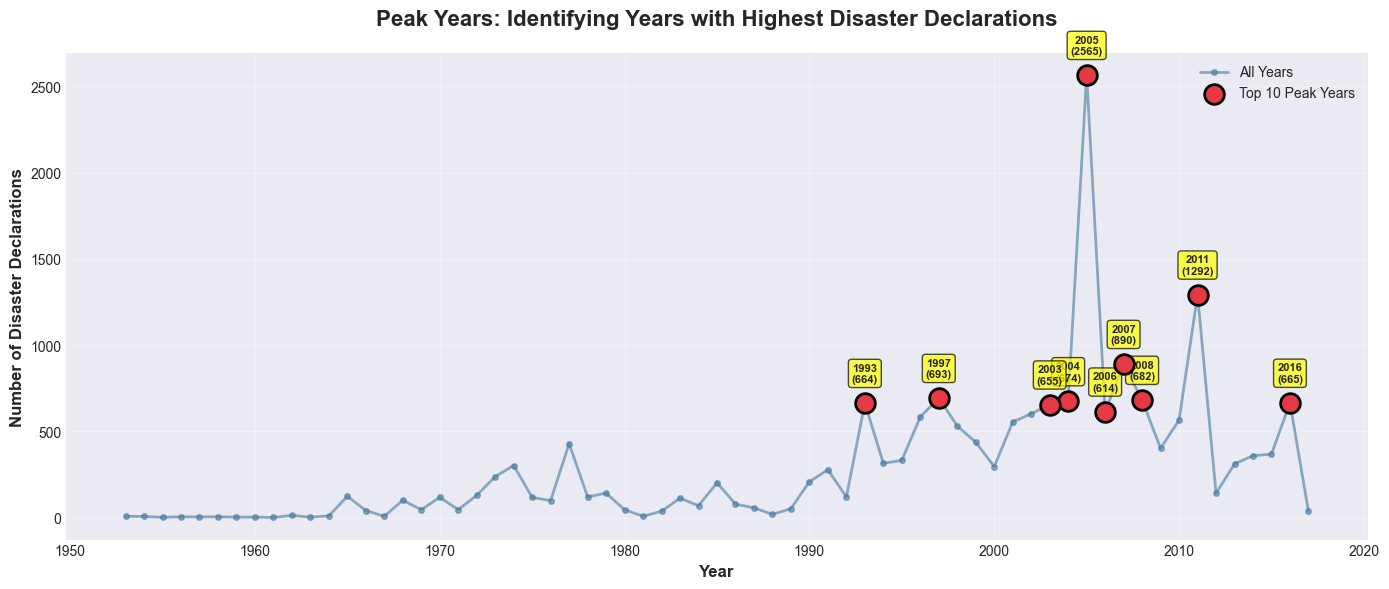

In [23]:
# Visualize peak years
plt.figure(figsize=(14, 6))

# Plot all years
plt.plot(yearly_counts['year'], yearly_counts['disaster_count'], 
         marker='o', linewidth=2, markersize=4, color='#457B9D', alpha=0.6, label='All Years')

# Highlight top 10 years
for idx, row in top_10_years.iterrows():
    plt.scatter(row['year'], row['disaster_count'], 
                color='#E63946', s=200, zorder=5, edgecolor='black', linewidth=2)
    plt.annotate(f"{int(row['year'])}\n({int(row['disaster_count'])})", 
                 xy=(row['year'], row['disaster_count']), 
                 xytext=(0, 15), textcoords='offset points',
                 ha='center', fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Add title and labels
plt.title('Peak Years: Identifying Years with Highest Disaster Declarations', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Disaster Declarations', fontsize=12, fontweight='bold')

# Add legend
plt.scatter([], [], color='#E63946', s=200, edgecolor='black', linewidth=2, label='Top 10 Peak Years')
plt.legend(fontsize=10)

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

### Interpretation: Advanced Time Insights

**Rolling Averages:**
- The smoothed trends confirm a clear long-term increase in disaster declarations
- Short-term volatility is reduced, making the underlying upward trajectory more apparent
- The acceleration in the rate of increase is particularly notable from the 1990s onward

**Growth Rate:**
- High variability in year-to-year growth rates indicates that disaster occurrence is influenced by both long-term trends and short-term events
- Positive growth years outnumber negative growth years, supporting the overall increasing trend
- Extreme positive spikes may correspond to particularly severe disaster seasons (e.g., major hurricane years)

**Peak Detection:**
- The peak years are concentrated in recent decades, reinforcing the trend of increasing disaster frequency
- These peak years likely correspond to major disaster events (e.g., Hurricane Katrina in 2005, Superstorm Sandy in 2012, active hurricane seasons)
- The clustering of peak years in recent times suggests either increasing disaster severity or improved reporting and declaration processes

---
## Summary and Key Findings

### Overall Insights:

1. **Increasing Trend:** There is a clear upward trend in disaster declarations over the past 70 years, with significant acceleration since the 1990s.

2. **Dominant Disaster Types:** 
   - Severe storms have become the most frequent disaster type
   - Floods and hurricanes remain consistently significant
   - Fire incidents show notable increase in recent years

3. **Strong Seasonality:** 
   - Late summer and early fall (August-October) are peak disaster months
   - Winter months show the lowest disaster activity
   - This pattern aligns with natural disaster seasons (hurricanes, wildfires, severe weather)

4. **Recent Intensification:** 
   - The past two decades show both higher baseline disaster counts and more extreme peak years
   - Year-to-year volatility has increased

5. **Implications:**
   - Climate change likely plays a role in increasing disaster frequency and intensity
   - Better preparedness and mitigation strategies are needed, especially for severe storms and fires
   - Seasonal patterns should inform resource allocation and preparedness planning
   - Continued monitoring and analysis are essential for effective disaster management

---
